# Compute the SNR for multipoles of the bispectrum

In [15]:
import numpy as np
from sympy import var
from matplotlib import pyplot as plt
from tqdm.auto import tqdm
from scipy import integrate
from numba import jit
import scipy
from classy import Class
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Polygon
from scipy.interpolate import interp1d
from scipy.integrate import odeint


#table of b_e and Q from doppler paper
euclid_data = np.loadtxt('Library/snr_surveyparams.txt')
#load table data for SKA
SKAO1Data = np.loadtxt('Library/SKAO1Data.txt')
SKAO2Data = np.loadtxt('Library/SKAO2Data.txt')
from Library.useful_funcs import *

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.rc('font', family='serif')
plt.rc('font', size='22')
#plt.rcParams['figure.dpi'] = 150
plt.rcParams['xtick.labelsize'] = 18
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['xtick.major.size'] = 10
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['xtick.minor.size'] = 5
plt.rcParams['xtick.minor.width'] = 1.5
plt.rcParams['ytick.major.size'] = 10
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['ytick.minor.size'] = 5
plt.rcParams['ytick.minor.width'] = 1.5

plt.rcParams['lines.linewidth'] = 1.5


# set color scheme
plt.style.use('tableau-colorblind10')
#colorblind10-tableua
colors = ["#006BA4", "#FF800E", "#ABABAB", "#595959","#5F9ED1", "#C85200", "#898989", "#A2C8EC", "#FFBC79", "#CFCFCF"]
colors = ["#0072B2", "#009E73", "#D55E00", "#CC79A7","#F0E442", "#56B4E9"] # seaborne-colorblind

#WA -0, RR -2 GR -1 - cos maybe it look nicer

In [3]:
def get_cosmo(h,Omega_b,Omega_cdm,Omega_m,A_s,n_s,sigma8=0):
    
    #Create a params dictionary
    params = {'output':'mPk,mTk',
                 'non linear':'halofit',
                 'Omega_b':Omega_b,
                 'Omega_cdm':Omega_cdm,#Omega_m-Omega_b,#
                 'h':h,
                 'n_s':n_s,
                 'A_s':A_s,#'n_s':n_s,'sigma8':0.828,#
                 'P_k_max_1/Mpc':k_max,
                 'z_max_pk':10. #Default value is 10
    }
    if sigma8 !=0:
        params = {'output':'mPk,mTk',
                 'non linear':'halofit',
                 'Omega_b':0.02242/h**2,
                 'Omega_cdm':Omega_m-Omega_b,#Omega_cdm,#
                 'h':h,
                 'n_s':n_s,
                 'sigma8':0.828,#'A_s':A_s,#'n_s':n_s,
                 'P_k_max_1/Mpc':k_max,
                 'z_max_pk':10. #Default value is 10
                 }
        

    #Initialize the cosmology and compute everything
    cosmo = Class()
    cosmo.set(params)
    cosmo.compute()
    
    return cosmo
#Need to specify the max wavenumber
k_max = 10 #UNITS: 1/Mpc # is also set to 10 later
#Start by specifying the cosmology  - planck best fit
h = 0.6766
Omega_b = 0.02242/h**2
Omega_cdm = 0.11933/h**2
Omega_m = Omega_cdm+Omega_b
A_s = 2.105e-9 
n_s = 0.9665

cosmo = get_cosmo(h,Omega_b,Omega_cdm,Omega_m,A_s,n_s)

#scoccimarro and noorikuhani cosmology
Omega_m = 0.32
sigma8 = 0.828
n_s = 0.968

cosmo_noor = get_cosmo(h,Omega_b,Omega_cdm,Omega_m,A_s,n_s,sigma8=sigma8)



## Import expression for each contributions

In [5]:
import sys
sys.path.append('bk_terms/')

from WA1 import *
from WA2 import *
from RR1 import *
from RR2 import *
from WARR import *

from WSGR import *
from GR1 import *
from GR2 import *
from GR0 import *
from PNG import *

from cov import COV as COV 

In [6]:
from bk_ws_1 import *
#from RR import *
#from WA import *

In [7]:
class WA_RR:#for all wide separation
    def l0(params,derivs,r,s):
        return WA2.l0(params,r,s)+WARR.l0(params,derivs,r,s)+RR2.l0(params,derivs,r,s)
    
    def l1(params,derivs,r,s):
        return WA1.l1(params,r,s) + RR1.l1(params,derivs,r,s)
    
    def l2(params,derivs,r,s):
        return WA2.l2(params,r,s)+WARR.l2(params,derivs,r,s)+RR2.l2(params,derivs,r,s)
    
class WA_RR_GR:
    def l0(params,derivs,betas,r,s):
        return WA2.l0(params,r,s) +RR2.l0(params,derivs,r,s)+GR2.l0(params,betas)+WAGR.l0(params,betas,r,s)+WARR.l0(params,derivs,r,s)+RRGR.l0(params,derivs,betas,r,s)
    
    def l1(params,derivs,betas,r,s):
        return WA1.l1(params,r,s) +RR1.l1(params,derivs,r,s)+GR1.l1(params,betas)
    l0(params,derivs,betas,r,s)
    

In [13]:
def bin_volume(z,delta_z=0.01,f_sky=0.365): # get d volume/dz
    return f_sky*4*np.pi*cosmo_functions.comoving_dist(z)**2 *(cosmo_functions.comoving_dist(z+delta_z)-cosmo_functions.comoving_dist(z-delta_z))

#unused code currently
#lets take average value integrated over redhsift bin 
def bin_average(func,zmin,zmax,fargs,l,V123=0,s123=0,cosmo_functions=cosmo_functions,func2=None,SN=True):
    """
    Returns average for a function over a redshift bin - uses gauss legendre integration
    could be sped up like numeric integration function by using numpy broadcasting and not using set scipy func
    """

    k1,k2,theta,r,s = fargs 
    k1 = k1[...,None]
    k2 = k2[...,None]
    theta = theta[...,None]
    
    funcl = getattr(func,"l"+str(l)) 
    if func2 != None:
        func2l = getattr(func2,"l"+str(l))
        
    def integrand(zz):
        derivs = cosmo_functions.get_derivs(zz)
        betas = cosmo_functions.get_beta_funcs(zz)
        params = cosmo_functions.get_params(k1,k2,theta,zz)
        args = get_args(func,params,derivs,betas,r,s)
        
        return bin_volume(zz)*funcl(*args)
    
    def integrandSN(zz,s123): # this doesnt really make sense tbh -look at the plot of the covariance

        derivs = cosmo_functions.get_derivs(zz)
        betas = cosmo_functions.get_beta_funcs(zz)
        params = cosmo_functions.get_params(k1,k2,theta,zz)
        args = get_args(func,params,derivs,betas,r,s)
        
        bk = funcl(*args)
        if func2 != None:  # for non-diagonal fisher terms
            args2 = get_args(func2,params,derivs,betas,r,s)
            bk2 = func2l(*args2)
        else:
            bk2 = bk
        
        bkbk = bk*np.conjugate(bk)
        nbar = cosmo_functions.n_g(zz)#get density [h/Mpc]^3

        s123 = s123[...,None]
        V123_ = V123[...,None]
        
        covbk = ((4*np.pi)**2 *s123*cov(params,nbar,V123_)/(2*l+1)**2)
        
        return bin_volume(zz)*bkbk/covbk
    
    def plotc(zz,s123):

        derivs = cosmo_functions.get_derivs(zz)
        betas = cosmo_functions.get_beta_funcs(zz)
        params = cosmo_functions.get_params(k1,k2,theta,zz)

        nbar = cosmo_functions.n_g(zz)#get density [h/Mpc]^3

        s123 = s123[...,None]
        V123_ = V123[...,None]
        
        covbk = cov(params,nbar,V123_)#((4*np.pi)**2 *s123*cov(params,nbar,V123_)/(2*l+1)**2)
        print(covbk.shape)
        plt.plot(zz,np.sum(1/covbk,axis=(0,1,2)))

        
    if SN:
        cov_lm = f'N{l}{m}'
        # Get the method from the class
        cov = getattr(COV, cov_lm)
        bk_bin_tmp, _ = scipy.integrate.fixed_quad(integrandSN,zmin,zmax,args=([s123]),n=10)
        ff = plotc(np.linspace(zmin,zmax,5),s123)
    else:
        bk_bin_tmp, _ = scipy.integrate.fixed_quad(integrand,zmin,zmax,n=10)
    
    norm, _ = scipy.integrate.fixed_quad(bin_volume,zmin,zmax,n=10)
    return bk_bin_tmp/norm

"""
r=0;s=0;
fargs = k1,k2,theta,r,s

zz= 1.35
cosmo_functions = CosmologicalFunctions(cosmo,'EUCLID')#,'DESI'
params = cosmo_functions.get_params(k1,k2,theta,zz)
derivs = cosmo_functions.get_derivs(zz)
betas = cosmo_functions.get_beta_funcs(zz)
#aas = bin_average(WA1,0.9,1.8,fargs,1,cosmo_functions=cosmo_functions,SN=False)
#test = WA1.l1(params,r,s)

#plot ratio of bin middle to bin averaged
#plt.plot(aas.imag/test.imag)
#plt.plot(aas.imag,'--')
#plt.yscale('log')"""

"\nr=0;s=0;\nfargs = k1,k2,theta,r,s\n\nzz= 1.35\ncosmo_functions = CosmologicalFunctions(cosmo,'EUCLID')#,'DESI'\nparams = cosmo_functions.get_params(k1,k2,theta,zz)\nderivs = cosmo_functions.get_derivs(zz)\nbetas = cosmo_functions.get_beta_funcs(zz)\n#aas = bin_average(WA1,0.9,1.8,fargs,1,cosmo_functions=cosmo_functions,SN=False)\n#test = WA1.l1(params,r,s)\n\n#plot ratio of bin middle to bin averaged\n#plt.plot(aas.imag/test.imag)\n#plt.plot(aas.imag,'--')\n#plt.yscale('log')"

In [9]:
#create empty dicts to fill with SNRs

if True:
    snr_GR1 = {}
    snr_RR1 = {} 
    snr_WA1 = {}
    snr_dip = {}
    snr_WS1 = {}
    z_mid = {}
    
    snr_dip_x1 = {}
    snr_dip_x2 = {}
    snr_dip_x3 = {}
    snr_dip_COM = {}


In [21]:
# int lets compute
def SNR(z_bin,func,l,m,r=0,s=0,cosmo_functions=cosmo_functions,k_max=0.1,func2=None,numeric=False):
    
    z_mid = (z_bin[0]+z_bin[1])/2 + 0.0001
    delta_z = (z_bin[1]-z_bin[0])/2

    V_s = bin_volume(z_mid,delta_z,f_sky=cosmo_functions.f_sky)# in [Mpc/h]^3 used to get fundamental fequency

    k_f = 2*np.pi*V_s**(-1/3)
    
    delta_k = 2*k_f

    k_bin = np.arange(delta_k,k_max,delta_k)
    
    #so lets say we remove signal where WA expansion breaks... for endpoint this is at # only relevant for DESI
    #remove from low redshift point of bin
    com_dist = cosmo_functions.comoving_dist(z_mid)#k_bin[0]
    k_cut = 2*np.pi/com_dist
    k_cut_bool = np.where(k_bin>k_cut,True,False)
    
    #print(k_cut)
    #print('k_f=',k_f)

    k1,k2,k3 = np.meshgrid(k_bin,k_bin,k_bin,indexing='ij')
    V123 = 8*np.pi**2*k1*k2*k3*(delta_k/k_f)**3 #from thin bin limit
    
    # so k1,k2,k3 have shape (N,N,N) - and so to do all realted array until we sum at the end
    #create bool for closed traingles with k1>k2>k3...
    tri_bool = np.full_like(k1,False).astype(np.bool_)
    s123 = np.ones_like(k1)
    for i in range(k1.shape[0]+1):
        if np.logical_or(i == 0,k_cut_bool[i-1]==False):
            continue
        for j in range(i+1):#enforce k1>k2
            if np.logical_or(j == 0,k_cut_bool[j-1]==False):
                continue
            for k in range(i-j,j+1):# enforce k2>k3 and triangle condition |k1-k2|<k3
                if np.logical_or(k == 0,k_cut_bool[k-1]==False):
                    continue

                #for indexing-
                ii = i-1
                jj = j-1
                kk = k-1
                tri_bool[ii,jj,kk] = True
                    
                #get s123
                if i==j:
                    if j==k:
                        #tri_bool[ii,jj,kk] = False
                        s123[ii,jj,kk]=6
                    else:
                        #tri_bool[ii,jj,kk] = False
                        s123[ii,jj,kk]=2
                elif j==k:
                    #tri_bool[ii,jj,kk] = False
                    s123[ii,jj,kk]=2

    #get theta from triagle condition - this create warnings from non-closed triangles
    # Handle cases where floating-point errors might cause cos_theta to go slightly beyond [-1, 1]
    cos_theta = (k3**2 - k1**2 - k2**2)/(2*k1*k2)
    cos_theta = np.where(np.isclose(np.abs(cos_theta), 1), np.sign(cos_theta), cos_theta) #need to get rid of rounding errors
    
    #if we want to suprress warnings from invalid values we can reset cos(theta) these terms are ignored anyway
    cos_theta = np.where(np.logical_or(cos_theta < -1, cos_theta > 1), 0, cos_theta)
    theta = np.arccos(cos_theta)

    fargs = k1,k2,theta,r,s
    
    def snr_part(func,func2,l,m,s123):
        """
        returns snr contribution for given triangle
        """
        if False:
            return bin_average(func,z_bin[0],z_bin[1],fargs,l,V123=V123,s123=s123,cosmo_functions=cosmo_functions,func2=func2)
        elif False:
            cov_lm = f'N{l}{m}'
            # Get the method from the class
            cov = getattr(COV, cov_lm)
            nbar = cosmo_functions.n_g(z_mid)#get density [h/Mpc]^3
            
            params = cosmo_functions.get_params(k1,k2,theta,z_mid)
            covar = (s123*cov(params,nbar,V123))
            bk = bin_average(func,z_bin[0],z_bin[1],fargs,l,cosmo_functions=cosmo_functions,SN=False)
            if func2 != None:  # for non-diagonal fisher terms
                bk2 = bin_average(func2,z_bin[0],z_bin[1],fargs,l,cosmo_functions=cosmo_functions,SN=False)
            else:
                bk2 = bk 
        else:
            cov_lm = f'N{l}{m}'
            # Get the method from the class
            cov = getattr(COV, cov_lm)
            
            derivs = cosmo_functions.get_derivs(z_mid)
            betas = cosmo_functions.get_beta_funcs(z_mid)
            params = cosmo_functions.get_params(k1,k2,theta,z_mid)
            
            
            nbar = cosmo_functions.n_g(z_mid)#get density [h/Mpc]^3

            covar = (s123*cov(params,nbar,V123))
            
            args = get_args(func,params,derivs,betas,r,s)
            
            funcl = getattr(func,"l"+str(l)) 
            if func2 != None:
                func2l = getattr(func2,"l"+str(l))

            bk = funcl(*args)
            if func2 != None:  # for non-diagonal fisher terms
                args2 = get_args(func2,params,derivs,betas,r,s)
                bk2 = func2l(*args2)
            else:
                bk2 = bk
            
            return bk*np.conjugate(bk2)/covar/(4*np.pi)**2 #(4pi)^2 comes from the way we define our basis for the multipoles
    
            
    def snr_part1(func,l,m,s123):
        """
        returns snr contribution for given triangle
        """
        cov_lm = f'N{l}{np.abs(m)}'
        # Get the method from the class
        cov = getattr(COV, cov_lm)
        
        bk = numeric_ylm(WA.full_1,l,m,params=flat_params,dfog=False,type_=0)
        
        nbar = cosmo_functions.n_g(z_mid)#get density [h/Mpc]^3
        covar = (s123*cov(params,nbar,V123)).flatten()[tri_bool.flatten()]

        return bk*np.conjugate(bk)/covar/(4*np.pi)**2
    
    #get snr  for all tri
    if numeric== False:
        tri_snr = snr_part(func,func2,l,m,s123)
        snr_tot = np.sum(tri_snr.flatten()[tri_bool.flatten()])
        
    else: #if we do numeric integrals - slightly more  cumbersome but work for single func
        params = cosmo_functions.get_params(k1,k2,theta,z_mid)
        flat_params = tuple_bool(params,tri_bool.flatten())
        
        tri_snr = snr_part1(func,l,m,s123)
        snr_tot = np.sum(tri_snr)

    return snr_tot

    
kmax = lambda zz: 0.1 *h*(1+zz)**(2/(2+n_s))
def get_SNR(func,l,m,r=0,s=0,func2=None,verbose=True,numeric=False,survey = 'EUCLID'):
    """
    Get SNR at several redshifts
    """
    if survey == 'EUCLID':
        z_lims=np.linspace(0.9,1.8,10)#z_lims=np.array([0.9,1.1,1.3,1.5,1.8])#
        z_mid =(z_lims[:-1] + z_lims[1:])/ 2 
        k_max_arr = np.ones_like(z_mid)*0.1#kmax(z_mid)
        cosmo_functions = CosmologicalFunctions(cosmo,'EUCLID')
    elif survey == 'BGS': # then DESI
        z_lims=np.linspace(0.0,0.6,7)
        z_mid =(z_lims[:-1] + z_lims[1:])/ 2
        k_max_arr = np.ones_like(z_mid)*0.1
        cosmo_functions = CosmologicalFunctions(cosmo,'BGS')
    elif survey == 'SKAO1': # then DESI
        
        z_lims=np.linspace(0.0,0.5,6)
        z_mid =(z_lims[:-1] + z_lims[1:])/ 2
        k_max_arr = np.ones_like(z_mid)*0.1
        cosmo_functions = CosmologicalFunctions(cosmo,'SKAO1')
    elif survey == 'SKAO2': # then DESI
        
        z_lims=np.linspace(0.1,2,20)
        z_mid =(z_lims[:-1] + z_lims[1:])/ 2
        k_max_arr = np.ones_like(z_mid)*0.1
        cosmo_functions = CosmologicalFunctions(cosmo,'SKAO2')
    elif survey == 'CVlim': # then DESI
        
        z_lims=np.linspace(0.1,3,30)
        z_mid =(z_lims[:-1] + z_lims[1:])/ 2
        k_max_arr = np.ones_like(z_mid)*0.1
        cosmo_functions = CosmologicalFunctions(cosmo,'yoyo')
    else:
        raise  ValueError('Survey not recognized... ')
              
    snr = np.zeros((len(z_lims)-1),dtype=np.complex64)
    for i in tqdm(range(len(z_lims)-1)) if verbose else range(len(z_lims)-1):
        z_bin = [z_lims[i],z_lims[i+1]]
        
        snr[i] = SNR(z_bin,func,l,m,r,s,cosmo_functions=cosmo_functions,k_max=k_max_arr[i],func2=func2,numeric=numeric)
    return snr, z_mid

#r=0;s=0
#survey = 'SKAO2'#'EUCLID'#'BGS'#
#snr_WA11_, z_mid = get_SNR(WA1,1,-1,r=r,s=s,survey=survey,numeric=True)

if False:
    r=0;s=0
    for i,survey in enumerate(['EUCLID','BGS','SKAO1','SKAO2']):#,'EUCLID','BGS','SKAO1','SKAO2'
        snr_GR1[survey], z_mid[survey] = get_SNR(GR1,1,0,survey=survey)
        snr_WS1[survey], z_mid[survey] = get_SNR(WA_RR,1,0,survey=survey)
        snr_dip[survey], z_mid[survey] = get_SNR(WA_RR_GR,1,0,r=r,s=s,survey=survey)
        snr_WA1[survey], z_mid[survey] = get_SNR(WA1,1,0,r=r,s=s,survey=survey)
        snr_RR1[survey], z_mid[survey] = get_SNR(RR1,1,0,r=r,s=s,survey=survey)
elif True:
    for i,survey in enumerate(['EUCLID','BGS','SKAO1','SKAO2']):#,'EUCLID','BGS','SKAO1','SKAO2'
        snr_GR1[survey], z_mid[survey] = get_SNR(GR1,1,0,survey=survey)
        snr_dip[survey], z_mid[survey] = get_SNR(WA_RR_GR,1,0,r=0,s=0,survey=survey)
        snr_dip_x1[survey], z_mid[survey] = get_SNR(WA_RR_GR,1,0,r=1,s=0,survey=survey)
        snr_dip_x2[survey], z_mid[survey] = get_SNR(WA_RR_GR,1,0,r=0,s=1,survey=survey)
        snr_dip_COM[survey], z_mid[survey] = get_SNR(WA_RR_GR,1,0,r=1/3,s=1/3,survey=survey)


  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

...

  0%|          | 0/19 [00:00<?, ?it/s]

  0%|          | 0/19 [00:00<?, ?it/s]

  0%|          | 0/19 [00:00<?, ?it/s]

  0%|          | 0/19 [00:00<?, ?it/s]

  0%|          | 0/19 [00:00<?, ?it/s]

In [57]:
survey = 'SKAO2'

print('WA=',np.sqrt(np.sum(snr_WA1[survey])))
print('RR=',np.sqrt(np.sum(snr_RR1[survey])))
print('WS=',np.sqrt(np.sum(snr_WS1[survey])))
print('GR=',np.sqrt(np.sum(snr_GR1[survey])))
print('ALL=',np.sqrt(np.sum(snr_dip[survey])))


#print('WA=',1/np.sqrt(np.sum(snr_WA1_x1[survey])))
#print('RR=',1/np.sqrt(np.sum(snr_RR1_x1[survey])))
#print('ALL=',1/np.sqrt(np.sum(snr_dip_x1[survey])))

WA= (4.818341+0j)
RR= (4.5885797+0j)
WS= (3.5757601+0j)
GR= (8.77183+0j)
ALL= (8.210079+0j)


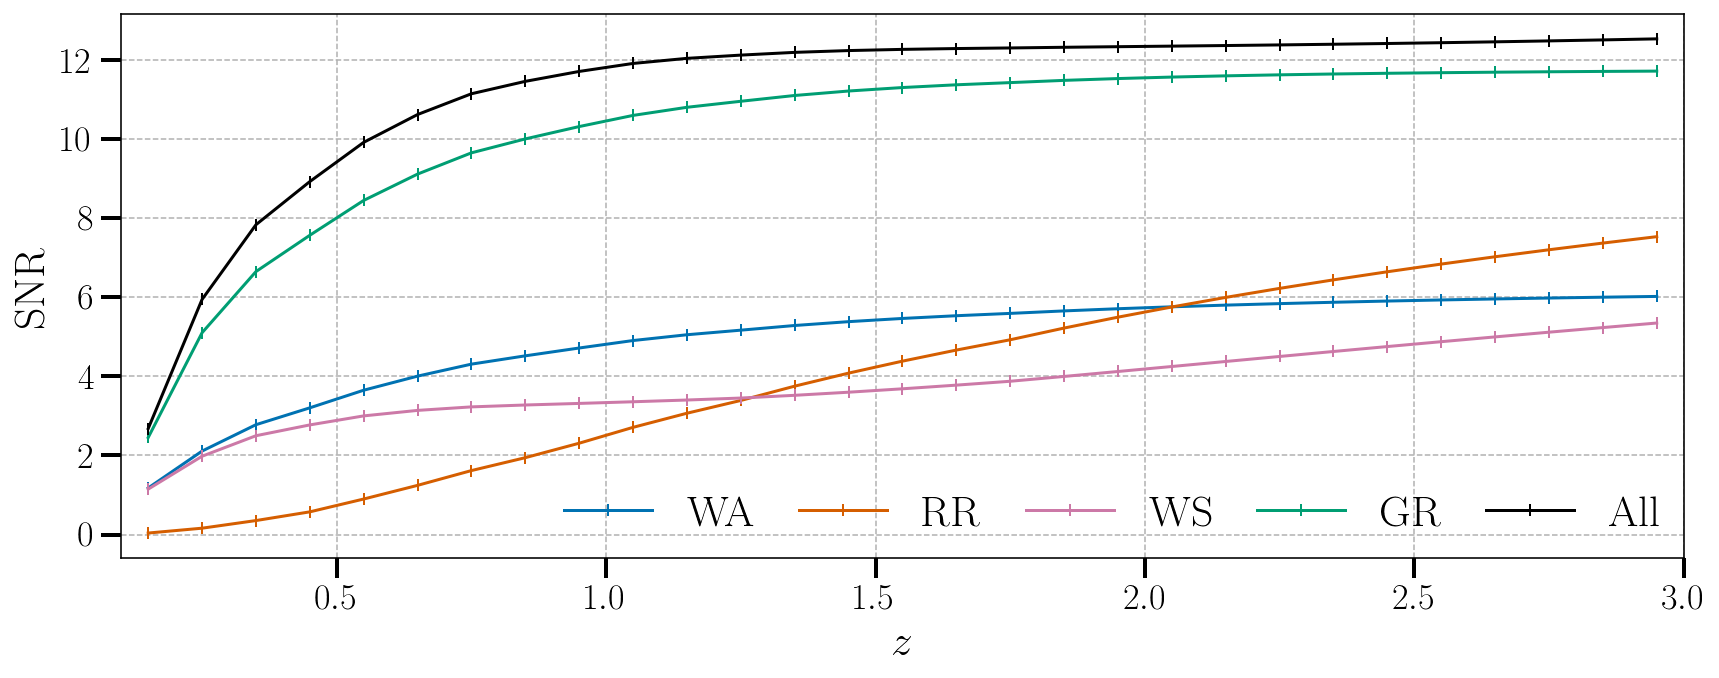

In [58]:
plt.figure(figsize=(14,5))   
if True:
    lstyles = ['-','--','-.'] #styles for different surveys
    for i,survey in enumerate(['CVlim']):# 'SKAO2','EUCLID','BGS'
        plt.plot(z_mid[survey],np.sqrt(np.cumsum(snr_WA1[survey].real)),lstyles[i],marker='|',label='WA',color=colors[0])
        plt.plot(z_mid[survey],np.sqrt(np.cumsum(snr_RR1[survey].real)),lstyles[i],marker='|',label='RR',color=colors[2])
        plt.plot(z_mid[survey],np.sqrt(np.cumsum(snr_WS1[survey].real)),lstyles[i],marker='|',label='WS',color=colors[3])
        plt.plot(z_mid[survey],np.sqrt(np.cumsum(snr_GR1[survey].real)),lstyles[i],marker='|',label='GR',color=colors[1])
        plt.plot(z_mid[survey],np.sqrt(np.cumsum(snr_dip[survey].real)),lstyles[i],marker='|',label='All',color='black')
        
plt.xlabel('$z$')
plt.grid(ls='--',lw=0.75)
plt.legend(ncol=5,frameon=False,title_fontsize=16,handlelength=2, columnspacing=1, handleheight=1, borderpad=0)

plt.xlim(0.1,3)
#plt.yscale('log')
plt.ylabel('SNR')
#plt.yscale('log')
#plt.ylim(0,20)
plt.savefig('plots/SNR_CVlim.png', bbox_inches='tight', dpi=400)

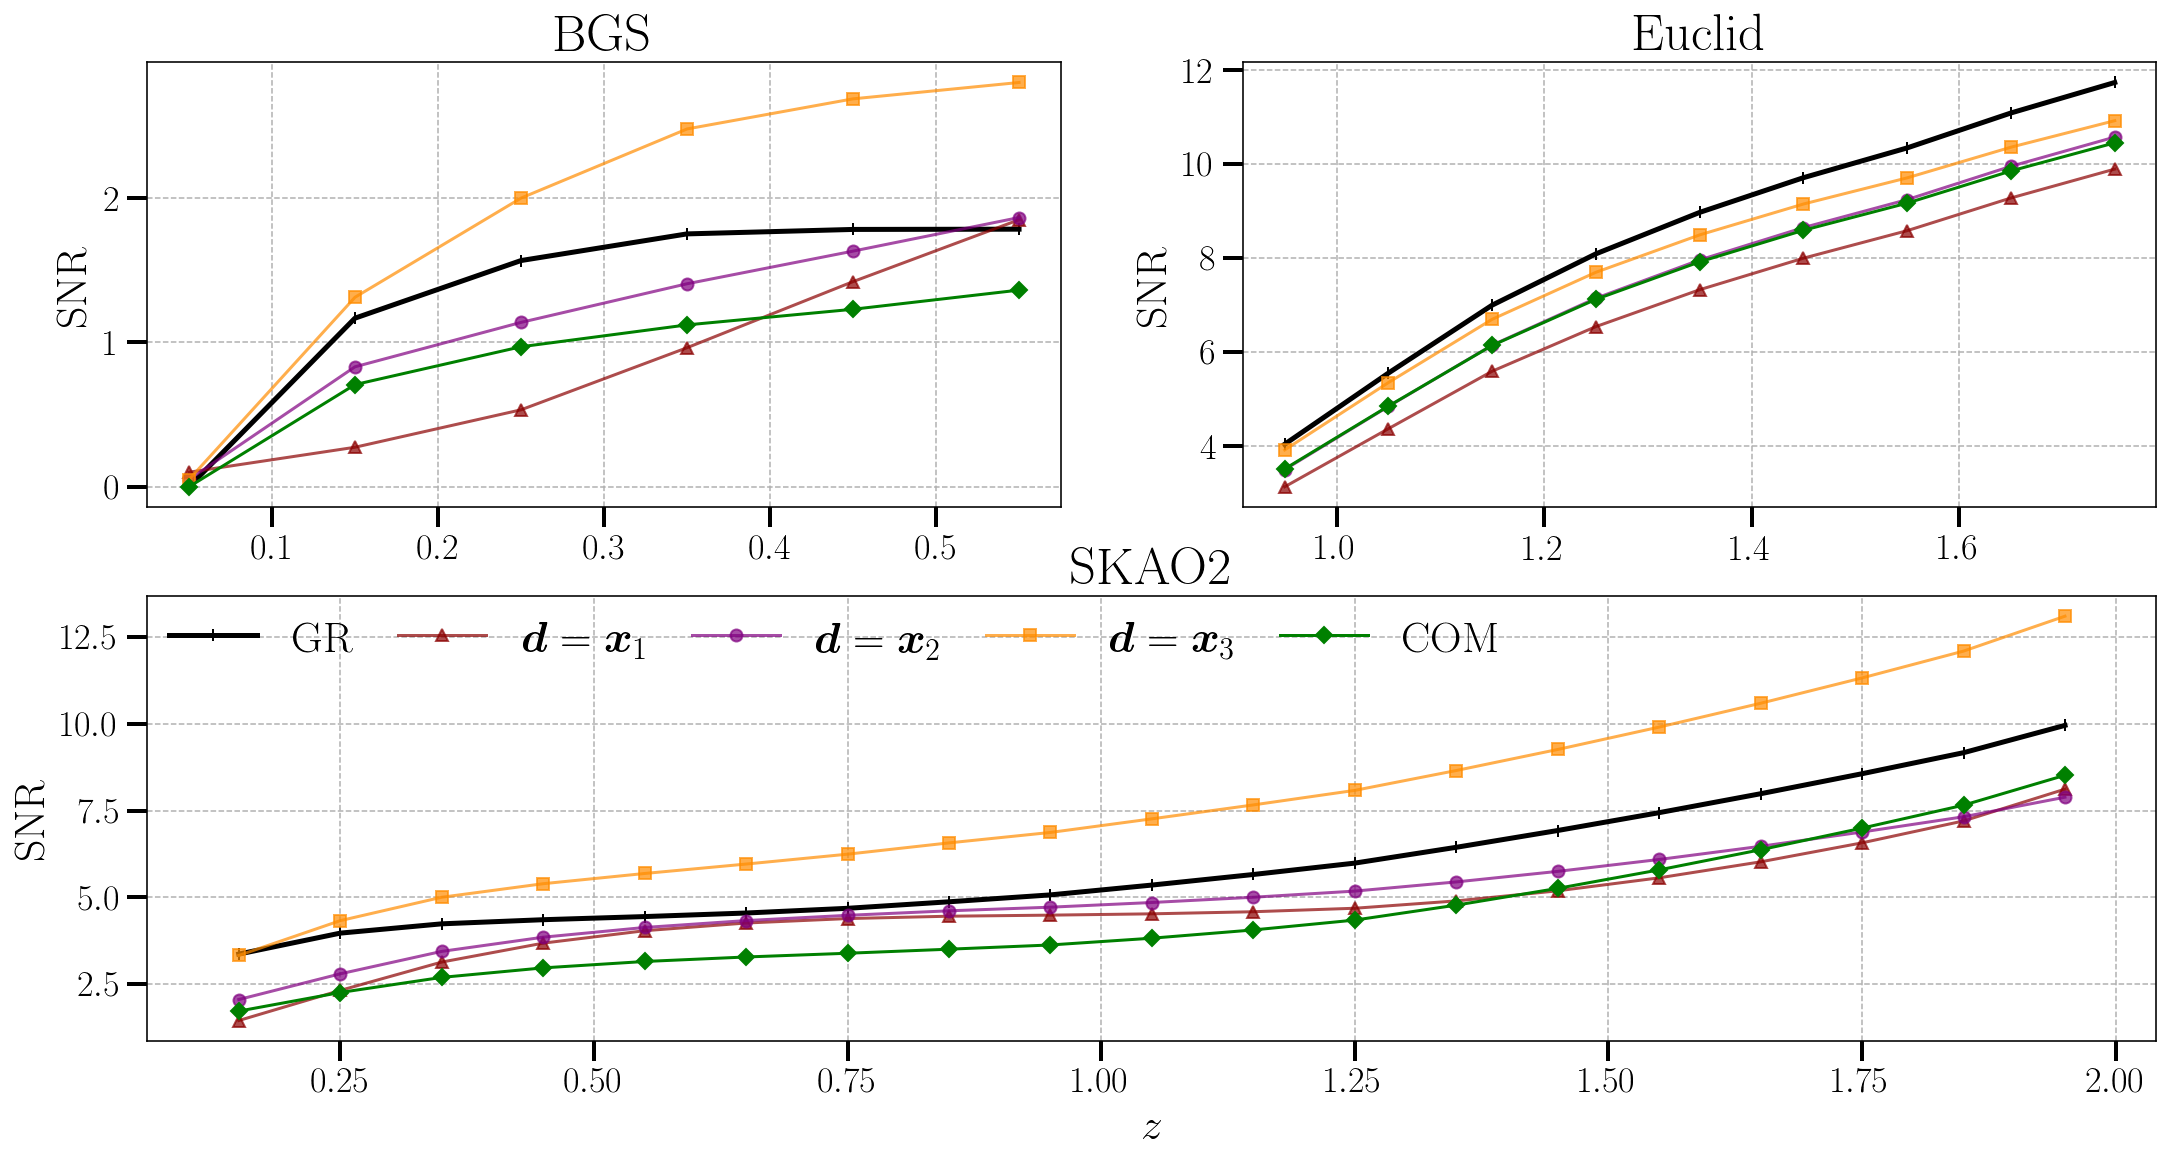

In [22]:
# Create figure
fig = plt.figure(figsize=(18,9))

axs = [[],[],[]]
# Create subplot 1 in the top left corner
axs[0] = plt.subplot2grid((2, 2), (0, 0))
axs[1] = plt.subplot2grid((2, 2), (0, 1))
axs[2] = plt.subplot2grid((2, 2), (1, 0), colspan=2)
for i,survey in enumerate(['BGS','EUCLID','SKAO2']): 
    axs[i].plot(z_mid[survey],np.sqrt(np.cumsum(snr_GR1[survey].real)),'-',marker='|',linewidth=2.5,label='GR',color='black')
    axs[i].plot(z_mid[survey],np.sqrt(np.cumsum(snr_dip_x1[survey].real)),'-',marker='^',label=r'$\boldsymbol{d}=\boldsymbol{x}_1$',color='darkred',alpha=0.7)
    axs[i].plot(z_mid[survey],np.sqrt(np.cumsum(snr_dip_x2[survey].real)),'-',marker='o',label=r'$\boldsymbol{d}=\boldsymbol{x}_2$',color='purple',alpha=0.7)
    axs[i].plot(z_mid[survey],np.sqrt(np.cumsum(snr_dip[survey].real)),'-',marker='s',label=r'$\boldsymbol{d}=\boldsymbol{x}_3$',color='darkorange',alpha=0.7)
    axs[i].plot(z_mid[survey],np.sqrt(np.cumsum(snr_dip_COM[survey].real)),'-',marker='D',label='COM',color='green',alpha=1)
    axs[i].grid(ls='--',lw=0.75)
    axs[i].set_title(survey)
    axs[i].set_ylabel('SNR')
    
axs[0].set_title('BGS')
axs[1].set_title('Euclid')
axs[2].set_title('SKAO2')

axs[2].legend(ncol=5,frameon=False,title_fontsize=16,handlelength=2, columnspacing=1, handleheight=1, borderpad=0)
axs[2].set_xlabel('$z$')


plt.savefig('plots/SNR_dipole.png', bbox_inches='tight', dpi=400)

## Fisher


$$F_{ij} =\sum_k \frac{\partial B}{\partial \theta_i}C^{-1}\frac{\partial B}{\partial \theta_j}$$

In [63]:
def fisherij(func,func2,l,m,survey='EUCLID'):

    return np.sum(get_SNR(func,l,m,func2=func2,verbose=False,survey=survey)[0].real)
fish_dict = {}

In [64]:
def get_fish(l,m,survey='EUCLID'):
    """
    Add fisher matrix to dict for given l and survey
    """
    
    func_list = [WA1,RR1,GR1]
    func_list0 = [ WA_RR_GR_wa, WA_RR_GR_rr, WA_RR_GR_gr]

    N = len(func_list)#get size of matrix
    fish_mat = np.zeros((N,N))
    print("computing covariance martrix for {} ...".format(survey))
    for i in tqdm(range(N)):
        for j in range(N):
            if l == 0:
                fish_mat[i,j] =  fisherij(func_list0[i],func_list0[j],l,m,survey=survey)
            else:    
                fish_mat[i,j] =  fisherij(func_list[i],func_list[j],l,m,survey=survey)
                
    return fish_mat
    
    
#fish_mat_El1 = get_fish(1,0,survey='EUCLID')
fish_mat_SKAl1 = get_fish(1,0,survey='SKAO2')
#fish_mat_Dl1 = get_fish(1,0,survey='BGS')

computing covariance martrix for SKAO2 ...


  0%|          | 0/3 [00:00<?, ?it/s]

[[1.79348543 1.73624056 0.1186029 ]
 [1.73624056 2.18061008 0.19656577]
 [0.1186029  0.19656577 0.02847274]]
[[ 0.03367773  0.00930819 -0.00775229]
 [ 0.00930819  0.15634317 -0.00544401]
 [-0.00775229 -0.00544401  0.01297192]]


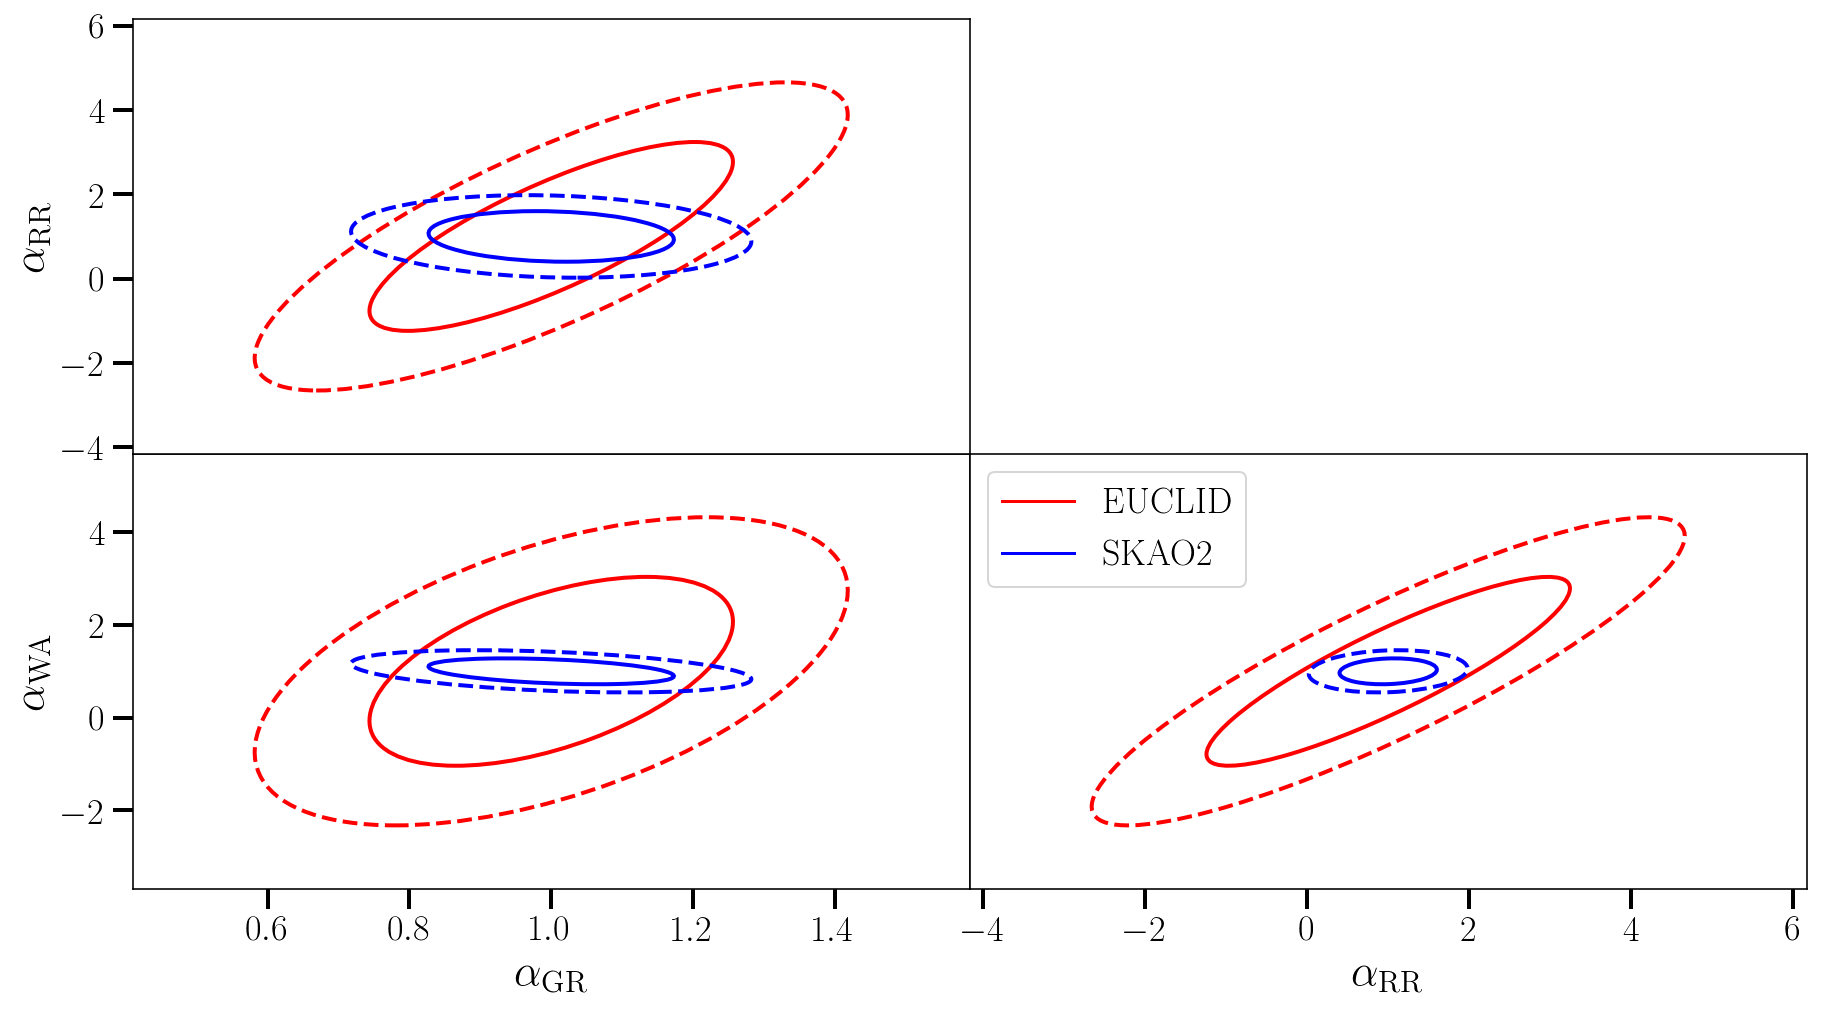

In [700]:
#from normal_corner import normal_corner
#from Library.normal_corner_adapted import *
from Library.normal_corner_ellipse import *


cov_mat = np.linalg.inv(fish_mat_El1)
cov_mat2 = np.linalg.inv(fish_mat_SKAl1)
print(cov_mat)
print(cov_mat2)
#cov_matdesi = np.linalg.inv(fish_matdesi)/3
#cov_mat= np.flip(cov_mat)

# Variable labels for plotting, as a list of strings
varlabels = ['$\\alpha_{\\rm WA}$','$\\alpha_{\\rm RR}$','$\\alpha_{\\rm GR}$']

# Mean matrix, as a numpy array
mean = np.array([1, 1, 1])

# Make a corner plot
fig1,axs = normal_corner(cov_mat,mean,varlabels,covm2=cov_mat2,mean2=mean,figsize=(15,8),scale_factor=3.5)
axs[0].plot([], [],'-',color='red', label='EUCLID')
axs[0].plot([], [],'-',color='blue', label='SKAO2')
axs[0].legend(loc='upper left',fontsize=18,markerscale=0.8)
#fig1,axs = normal_corner(cov_mat,mean,varlabels,scale_factor=3)
#axs[0].axhline(1+1.52*np.sqrt(cov_matdesi[0,0]),linestyle='--')
#axs[1].axhline(1+1.52*np.sqrt(cov_matdesi[0,0]),linestyle='--')
#axs[0].axvline(1+1.52*np.sqrt(cov_matdesi[1,1]),linestyle='--')
#axs[1].axvline(1+1.52*np.sqrt(cov_matdesi[2,2]),linestyle='--')

#axs[2].axhline(1+1.52*np.sqrt(cov_matdesi[1,1]),linestyle='--')
#axs[2].axvline(1+1.52*np.sqrt(cov_matdesi[2,2]),linestyle='--')
plt.savefig('plots/fisher.png', bbox_inches='tight', dpi=400)
plt.show()


In [19]:
def numeric_ylm(func,l,m,r=0,s=0,params=params,derivs=derivs,betas=betas,dfog=False,type_ = 0):
    """
    does numerical integration with double legendre guass integration implemented in int_gl_dbl()
    is vectorised just last two axes need to be dimension 1 
    """

    def int_gl_dbl(func,*args):
        """
        implements double legendre guass integral for mu and phi integrals - extension and specialiation
        of integrate.fixed_quad()
        """
        n=20

        nodes, weights = np.polynomial.legendre.leggauss(n)#legendre gauss - get nodes and weights for given n
        nodes = np.real(nodes)
        mesh_nodes1,mesh_nodes2 = np.meshgrid(nodes,nodes,indexing ='ij')        #mesh gridding as 2d
        mesh_weights1,mesh_weights2 = np.meshgrid(weights,weights,indexing ='ij')

        phi_nodes = (2*np.pi)*(mesh_nodes1+1)/2.0 #sample phi range [0,2*np.pi]
        mu_nodes = (2)*(mesh_nodes2+1)/2.0 - 1 # sample mu range [-1,1] - so this is the natural gauss legendre range!

        return (2*np.pi)/2.0 * np.sum(mesh_weights1*mesh_weights2*func(phi_nodes, mu_nodes, *args), axis=(-2,-1)) #sum over last two axes (mu and phi)
    
    k1,k2,k3,theta,Pk1,Pk2,Pk3,Pkd1,Pkd2,Pkd3,Pkdd1,Pkdd2,Pkdd3,d,K,C,f,D1,b1,b2,g2 = params
    def integrand(phi,mu,*args):
        ylm = scipy.special.sph_harm(m, l, phi, np.arccos(mu))
        expression = func(*args,mu,phi,r=r,s=s)
        
        if dfog:
            sigma = 5
            mu2 = mu*np.cos(theta)+ (1-mu**2)**(1/2) *np.sin(theta)*np.cos(phi)
            mu3 = -(mu*k1+mu2*k2)/k3
            dfog_val = np.exp(-(1/2)*((k1*mu)**2+(k2 *mu2)**2+(k3 *mu3)**2)*sigma**2)
        else:
            dfog_val = 1
        return np.conjugate(ylm)*expression*dfog_val
    
    if type_ == 0:
        result = int_gl_dbl(integrand,params)
    elif type_ == 1:
        result = int_gl_dbl(integrand,params,derivs)
    elif type_ == 2:
        result = int_gl_dbl(integrand,params,betas)
    elif type_ == 3:
        result = int_gl_dbl(integrand,params,derivs,betas)
        
    return result